In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
# Load the dataset
df = pd.read_csv(r'C:\Users\Dhairy Jani\upi-fraud-detector\data\raw\creditcard.csv')
print(df)

            Time         V1         V2        V3        V4        V5  \
0            0.0  -1.359807  -0.072781  2.536347  1.378155 -0.338321   
1            0.0   1.191857   0.266151  0.166480  0.448154  0.060018   
2            1.0  -1.358354  -1.340163  1.773209  0.379780 -0.503198   
3            1.0  -0.966272  -0.185226  1.792993 -0.863291 -0.010309   
4            2.0  -1.158233   0.877737  1.548718  0.403034 -0.407193   
...          ...        ...        ...       ...       ...       ...   
284802  172786.0 -11.881118  10.071785 -9.834783 -2.066656 -5.364473   
284803  172787.0  -0.732789  -0.055080  2.035030 -0.738589  0.868229   
284804  172788.0   1.919565  -0.301254 -3.249640 -0.557828  2.630515   
284805  172788.0  -0.240440   0.530483  0.702510  0.689799 -0.377961   
284806  172792.0  -0.533413  -0.189733  0.703337 -0.506271 -0.012546   

              V6        V7        V8        V9  ...       V21       V22  \
0       0.462388  0.239599  0.098698  0.363787  ... -0.01830

In [8]:
# First look at the data
print("The Shape of data is:", df.shape)

The Shape of data is: (284807, 31)


In [11]:
print("\nFirst 5 rows:")
df.head()


First 5 rows:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [12]:
# Check column names and data types
print("\nColumn Names:")
print(df.columns.tolist())
print("\nData Types:")
print(df.dtypes)


Column Names:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

Data Types:
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object


In [13]:
# Check missing values
print("Missing Values in each column:")
print(df.isnull().sum())

Missing Values in each column:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


In [14]:
# Check class distribution - how many fraud vs legitimate
print("Class Distribution:")
print(df['Class'].value_counts())
print("\nFraud Percentage:")
print(df['Class'].value_counts(normalize=True) * 100)

Class Distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Fraud Percentage:
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


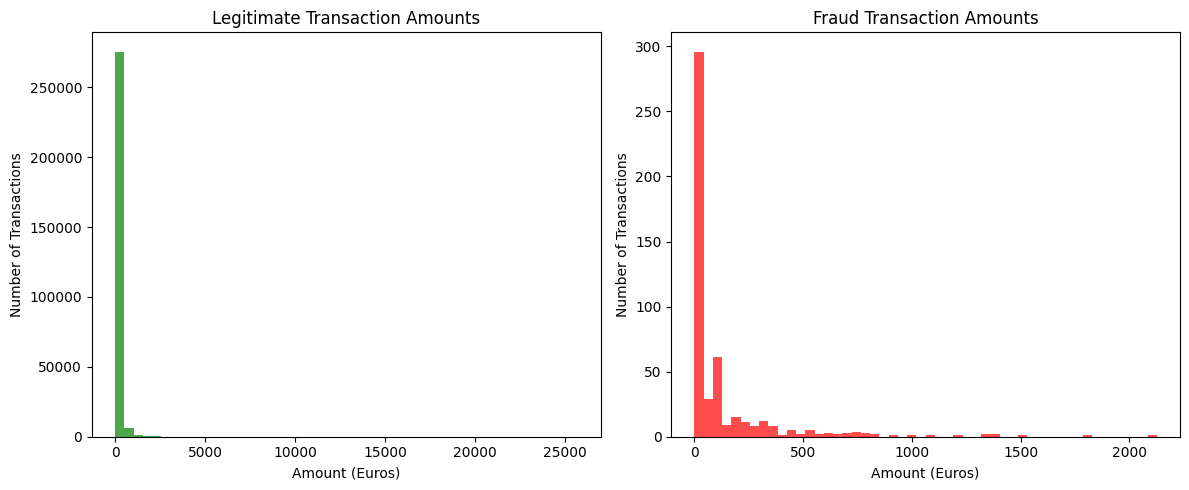

In [15]:
# Amount distribution - Fraud vs Legitimate
plt.figure(figsize=(12, 5))

# Legitimate transactions amount
plt.subplot(1, 2, 1)
plt.hist(df[df['Class'] == 0]['Amount'], bins=50, color='green', alpha=0.7)
plt.title('Legitimate Transaction Amounts')
plt.xlabel('Amount (Euros)')
plt.ylabel('Number of Transactions')

# Fraud transactions amount
plt.subplot(1, 2, 2)
plt.hist(df[df['Class'] == 1]['Amount'], bins=50, color='red', alpha=0.7)
plt.title('Fraud Transaction Amounts')
plt.xlabel('Amount (Euros)')
plt.ylabel('Number of Transactions')

plt.tight_layout()
plt.show()

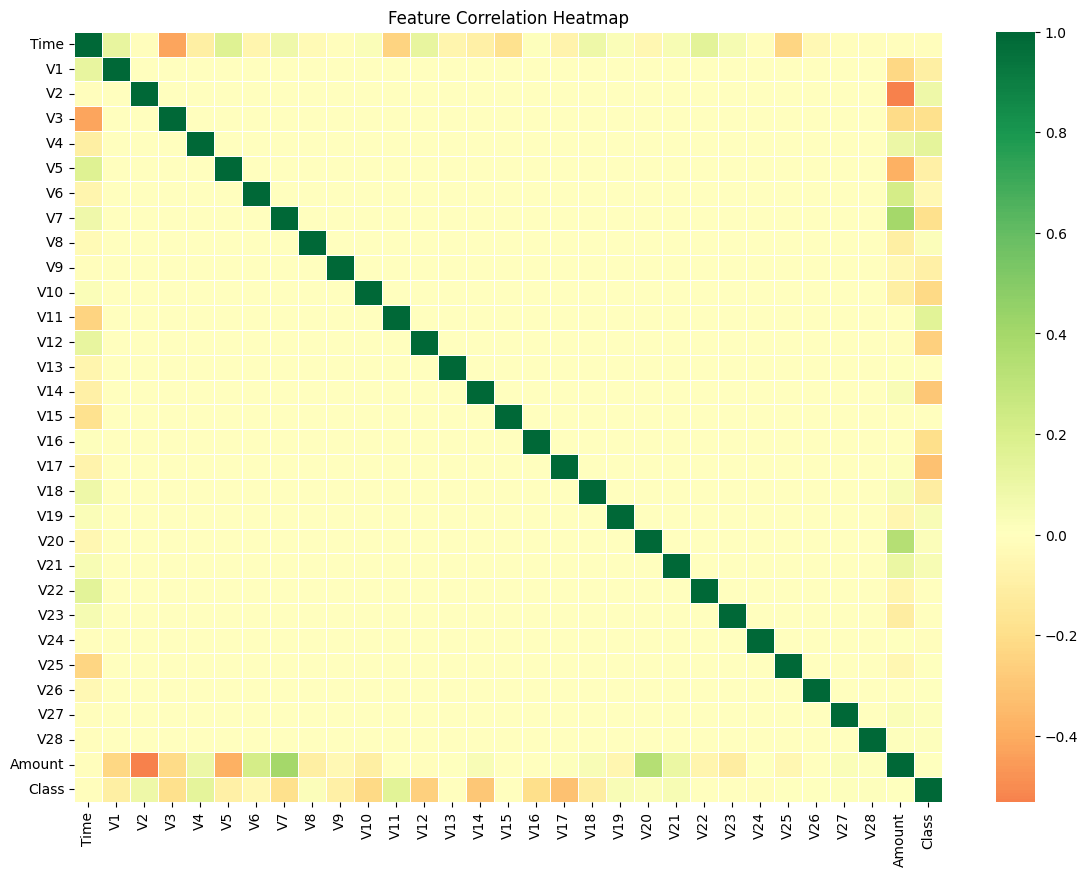

In [16]:
# Correlation heatmap - which features are most related to fraud
plt.figure(figsize=(14, 10))
corr = df.corr()
sns.heatmap(corr, cmap='RdYlGn', center=0, linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.show()

In [17]:
# Which features are most correlated with Class (fraud)?
corr_with_fraud = df.corr()['Class'].sort_values(ascending=False)
print("Top features correlated with Fraud:")
print(corr_with_fraud)

Top features correlated with Fraud:
Class     1.000000
V11       0.154876
V4        0.133447
V2        0.091289
V21       0.040413
V19       0.034783
V20       0.020090
V8        0.019875
V27       0.017580
V28       0.009536
Amount    0.005632
V26       0.004455
V25       0.003308
V22       0.000805
V23      -0.002685
V15      -0.004223
V13      -0.004570
V24      -0.007221
Time     -0.012323
V6       -0.043643
V5       -0.094974
V9       -0.097733
V1       -0.101347
V18      -0.111485
V7       -0.187257
V3       -0.192961
V16      -0.196539
V10      -0.216883
V12      -0.260593
V14      -0.302544
V17      -0.326481
Name: Class, dtype: float64


In [18]:
# Compare amount statistics - Fraud vs Legitimate
print("Legitimate Transaction Amount Stats:")
print(df[df['Class'] == 0]['Amount'].describe())

print("\nFraud Transaction Amount Stats:")
print(df[df['Class'] == 1]['Amount'].describe())

Legitimate Transaction Amount Stats:
count    284315.000000
mean         88.291022
std         250.105092
min           0.000000
25%           5.650000
50%          22.000000
75%          77.050000
max       25691.160000
Name: Amount, dtype: float64

Fraud Transaction Amount Stats:
count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64


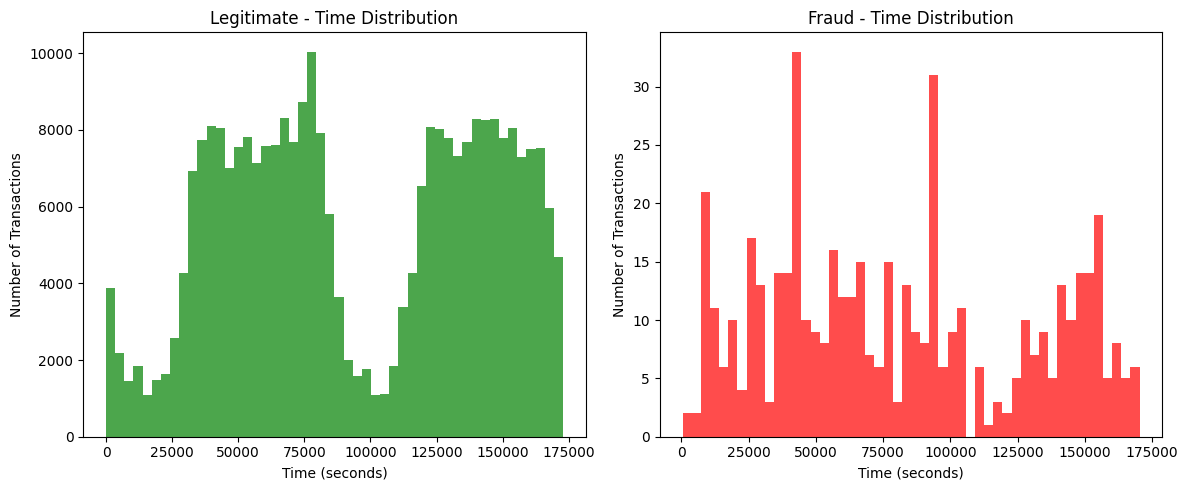

In [19]:
# When do fraud transactions happen?
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(df[df['Class'] == 0]['Time'], bins=50, color='green', alpha=0.7)
plt.title('Legitimate - Time Distribution')
plt.xlabel('Time (seconds)')
plt.ylabel('Number of Transactions')

plt.subplot(1, 2, 2)
plt.hist(df[df['Class'] == 1]['Time'], bins=50, color='red', alpha=0.7)
plt.title('Fraud - Time Distribution')
plt.xlabel('Time (seconds)')
plt.ylabel('Number of Transactions')

plt.tight_layout()
plt.show()

In [20]:
# Full dataset summary
print("Dataset Summary:")
print(df.describe().round(2))

Dataset Summary:
            Time         V1         V2         V3         V4         V5  \
count  284807.00  284807.00  284807.00  284807.00  284807.00  284807.00   
mean    94813.86       0.00       0.00      -0.00       0.00       0.00   
std     47488.15       1.96       1.65       1.52       1.42       1.38   
min         0.00     -56.41     -72.72     -48.33      -5.68    -113.74   
25%     54201.50      -0.92      -0.60      -0.89      -0.85      -0.69   
50%     84692.00       0.02       0.07       0.18      -0.02      -0.05   
75%    139320.50       1.32       0.80       1.03       0.74       0.61   
max    172792.00       2.45      22.06       9.38      16.88      34.80   

              V6         V7         V8         V9  ...        V21        V22  \
count  284807.00  284807.00  284807.00  284807.00  ...  284807.00  284807.00   
mean        0.00      -0.00       0.00      -0.00  ...       0.00      -0.00   
std         1.33       1.24       1.19       1.10  ...       0.73  